In [ ]:
pip install deepinv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 850.4/850.4 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 35.8 MB/s eta 0:00:00


In [ ]:
import deepinv as dinv
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import numpy as np

In [ ]:
def build_SPC_physics(rate: float, img_size: tuple[int], noise_lvl: float, ordering: str, device: torch.device):

    m = int(rate*img_size[1]*img_size[2])
    physics = dinv.physics.SinglePixelCamera(
        m=m,
        img_size=img_size,
        noise_model=dinv.physics.GaussianNoise(sigma=noise_lvl),
        device=device,
        ordering=ordering,
    )

    return physics

from deepinv.physics.blur import gaussian_blur

def build_blur_physics(n: int, sigma_noise: float, blur_sigma: float, grayscale: bool, device: torch.device):
    channels = 1 if grayscale else 3
    blur_filter = gaussian_blur(sigma=blur_sigma).to(device)
    if blur_filter.shape[1] == 1 and channels > 1:
        blur_filter = blur_filter.repeat(1, channels, 1, 1)
    physics = dinv.physics.BlurFFT(
        img_size=(channels, n, n),
        filter=blur_filter,
        device=device,
        noise_model=dinv.physics.GaussianNoise(sigma=sigma_noise),
    )
    return physics

def build_Inpainting_physics(keep_rate: float, img_size: tuple[int], noise_lvl: float, device: torch.device):
    # 1. Crear una máscara del tamaño de la imagen llena de unos
    mask = torch.ones(img_size).to(device)

    # 2. Generar ruido uniforme del mismo tamaño y crear la máscara binaria
    # Si el valor aleatorio es menor a keep_rate, el píxel se queda (1), si no, se borra (0)
    mask = (torch.rand_like(mask) < keep_rate).float()

    # Definir la física de Inpainting
    physics = dinv.physics.Inpainting(
        mask=mask,
        tensor_size=img_size,
        noise_model=dinv.physics.GaussianNoise(sigma=noise_lvl),
        device=device
    )
    return physics

In [ ]:
def set_seed(seed: int):
    # os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # torch.use_deterministic_algorithms(mode=True)

In [ ]:
class PGDStep(dinv.models.Reconstructor):
    def __init__(self, data_fidelity, prior, stepsize, lambd):
        super().__init__()
        self.data_fidelity = data_fidelity
        self.prior = prior
        self.stepsize = stepsize
        self.lambd = lambd

    def step(self, x_k, y, physics, **kwargs):
        """Algorithm PGD Step.

        :param torch.Tensor x_k: reconstruction at k
        :param torch.Tensor y: measurements.
        :param dinv.physics.Physics physics: measurement operator.
        :return: torch.Tensor: reconstructed image.
        """
        u = x_k - self.stepsize * self.data_fidelity.grad(
            x_k, y, physics
        )  # Gradient step
        x_k = self.prior.prox(
            u, sigma_denoiser=self.lambd * self.stepsize
        )  # Proximal step with denoiser

        return x_k

In [ ]:
import torch

class AccStep():
  """
  Class to apply different acceleration schemes
  about a base operator (e.g. PGDStep.step).
  """

  def __init__(self, rho=0.9, max_m=5):
    self.rho = rho
    self.max_m = max_m  # Memoria máxima para no saturar RAM
    self.reset()

  def reset(self):
    # To FISTA
    self.t = 1.0

    # Internal States
    self.x_prev = None      # x_{k} (entrada al operador)
    self.z_prev = None      # z_{k} (salida acelerada)

    # To Anderson
    self.x_hist = []        # g(x_k)'s history
    self.f_hist = []      # r_k's history

  def step(self, x_next, action):
    """
    x_next: resultado del operador g(x_prev)
    action: esquema de aceleración
    """
    # History
    if self.x_prev is not None:
      # Residual r_k = g(x_k) - x_k
      res = (x_next - self.x_prev).detach()

      self.x_hist.append(x_next.detach())
      self.f_hist.append(res)

      # Keep the history of len m
      if len(self.x_hist) > self.max_m:
        self.x_hist.pop(0)
        self.f_hist.pop(0)

    # Select the accelerator
    if action == 0:
      z_next = self._no_accel(x_next)

    elif action == 1:
      z_next = self._fista_classic(x_next)

    elif action == 2:
      z_next = self._fixed_momentum(x_next)

    elif action in [3, 4, 5]:
      m = action
      z_next = self._anderson_math(x_next, m)

    else:
      raise ValueError("Unknown action")

    # Update x & z
    self.x_prev = z_next.detach()
    self.z_prev = z_next.detach()

    return z_next

  # --------------------------
  # Actions
  # --------------------------

  def _no_accel(self, x_next):
    return x_next

  def _fista_classic(self, x_next):
    if self.z_prev is None:
      return x_next

    t_new = 0.5 * (1.0 + (1.0 + 4.0 * self.t**2) ** 0.5)
    beta = (self.t - 1.0) / t_new

    # z_{k+1} = x_{k+1} + beta * (x_{k+1} - x_k)
    z_next = x_next + beta * (x_next - self.x_prev)

    self.t = t_new
    return z_next

  def _fixed_momentum(self, x_next):
    if self.x_prev is None:
      return x_next

    z_next = x_next + self.rho * (x_next - self.x_prev)
    return z_next

  def _restart(self, x_next):
    self.t = 1.0
    return x_next

  def _anderson_math(self, x_next, m):
    """
    Compute Anderson Acceleration with memory (m).
    """
    k = len(self.f_hist)

    # We need at least 2 samples.
    if k < 2:
      return x_next

    # Use the last m elements
    actual_m = min(k, m)
    f_samples = self.f_hist[-actual_m:]
    x_samples = self.x_hist[-actual_m:]

    # Build matrices
    R = torch.stack([ri.reshape(-1) for ri in f_samples], dim=1)
    X = torch.stack([xi.reshape(-1) for xi in x_samples], dim=1)

    device = x_next.device
    n_cols = R.shape[1]

    # System KKT: min ||R @ alpha||^2 s.t. sum(alpha) = 1
    G = R.t() @ R
    G += torch.eye(n_cols, device=device) * 1e-6  # Reg to stability

    KKT = torch.zeros((n_cols + 1, n_cols + 1), device=device)
    KKT[:n_cols, :n_cols] = G
    KKT[:n_cols, n_cols] = 1.0
    KKT[n_cols, :n_cols] = 1.0

    rhs = torch.zeros(n_cols + 1, device=device)
    rhs[n_cols] = 1.0

    try:
      sol = torch.linalg.solve(KKT, rhs)
      alpha = sol[:n_cols]
      # linear combination of the operator's outputs
      z_next = (X @ alpha).reshape_as(x_next)
    except RuntimeError:
      # If solver fails, return without accelerating
      z_next = x_next

    return z_next


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
set_seed(seed=0)

metric = dinv.metric.PSNR()

physics = build_SPC_physics(0.3, (3, 256, 256), 0.0, "zig_zag", device)
# physics = build_Inpainting_physics(keep_rate=0.2, img_size=(3, 256, 256), noise_lvl=0.01, device=device)
# physics = build_blur_physics(256, 0.1, 1.5, False, device)
print(physics.noise_model.sigma)
physics.noise_model.sigma = torch.tensor(0.1, device=device)
print(physics.noise_model.sigma)

x = dinv.utils.load_example("butterfly.png", device=device)
print(x.shape)

y = physics(x)
print(y.shape)

x0 = physics.A_adjoint(y)

Using device: cuda
tensor(0., device='cuda:0')
tensor(0.1000, device='cuda:0')
torch.Size([1, 3, 256, 256])
torch.Size([1, 3, 256, 256])


[0.         0.01010101 0.02020202 0.03030303 0.04040404 0.05050505
 0.06060606 0.07070707 0.08080808 0.09090909 0.1010101  0.11111111
 0.12121212 0.13131313 0.14141414 0.15151515 0.16161616 0.17171717
 0.18181818 0.19191919 0.2020202  0.21212121 0.22222222 0.23232323
 0.24242424 0.25252525 0.26262626 0.27272727 0.28282828 0.29292929
 0.3030303  0.31313131 0.32323232 0.33333333 0.34343434 0.35353535
 0.36363636 0.37373737 0.38383838 0.39393939 0.4040404  0.41414141
 0.42424242 0.43434343 0.44444444 0.45454545 0.46464646 0.47474747
 0.48484848 0.49494949 0.50505051 0.51515152 0.52525253 0.53535354
 0.54545455 0.55555556 0.56565657 0.57575758 0.58585859 0.5959596
 0.60606061 0.61616162 0.62626263 0.63636364 0.64646465 0.65656566
 0.66666667 0.67676768 0.68686869 0.6969697  0.70707071 0.71717172
 0.72727273 0.73737374 0.74747475 0.75757576 0.76767677 0.77777778
 0.78787879 0.7979798  0.80808081 0.81818182 0.82828283 0.83838384
 0.84848485 0.85858586 0.86868687 0.87878788 0.88888889 0.89898

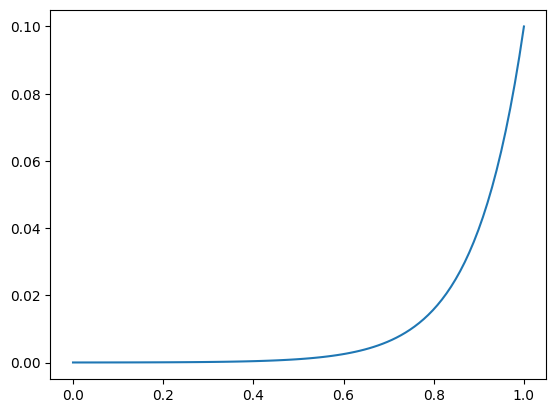

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

array = np.linspace(0, 1, 100)
print(array)
current_sigma = 10**(-5 + torch.rand(1).item()*4)
current_sigma
distr = 10**(-5 + array*4)
print(distr.min())
plt.plot(array, 10**(-5 + array*4))

In [ ]:
# Reconstruction Algorithm

data_fidelity = dinv.optim.L2()
denoiser = dinv.models.DnCNN(device=device, pretrained="download_lipschitz")
prior = dinv.optim.PnP(denoiser=denoiser)
stepsize = 0.1 / physics.compute_norm(physics.A_adjoint(y), tol=1e-3).item()
_lambda = 0.01

pgd = PGDStep(data_fidelity=data_fidelity, prior=prior,
              stepsize=stepsize, lambd=_lambda)

max_iter = 500

# --- Experiment ---
actions_to_test = [0, 1, 2, 3, 4, 5]
action_labels = {
    0: "PGD Puro", 1: "FISTA", 2: "Momentum", 3: "AA (m=3)", 4: "AA (m=4)", 5: "AA (m=5)"
    }

results = {action: [] for action in actions_to_test}
residual_results = {action: [] for action in actions_to_test}
fid_results = {action: [] for action in actions_to_test}

with torch.inference_mode():
  for action in actions_to_test:
    # Nueva instancia del acc para probar los aceleradores por separado
    acc = AccStep(rho=0.9, max_m=5)
    z_k = x0.clone() # Empezar siempre desde el mismo punto inicial
    x_next = x0.clone()
    desc_text = f"Action {action}: {action_labels[action]}"
    for k in tqdm(range(max_iter), desc=desc_text, colour='magenta'):
      # Paso base del optimizador
      x_old = x_next
      x_next = pgd.step(z_k, y, physics)

      # Aplicar la aceleración elegida
      z_next = acc.step(x_next, action)

      # Guardar Metrics
      results[action].append(metric(z_next, x).item())
      step_norm = torch.norm(x_next - x, p=2).item() / torch.norm(x, p=2).item()
      fidelity = data_fidelity(z_next, y, physics)
      residual_results[action].append(step_norm)
      fid_results[action].append(fidelity.item())

      z_k = z_next

Power iteration converged at iteration 2, ||A^T A||_2=1.00


Action 5: AA (m=5): 100%|██████████| 500/500 [00:12<00:00, 41.01it/s]


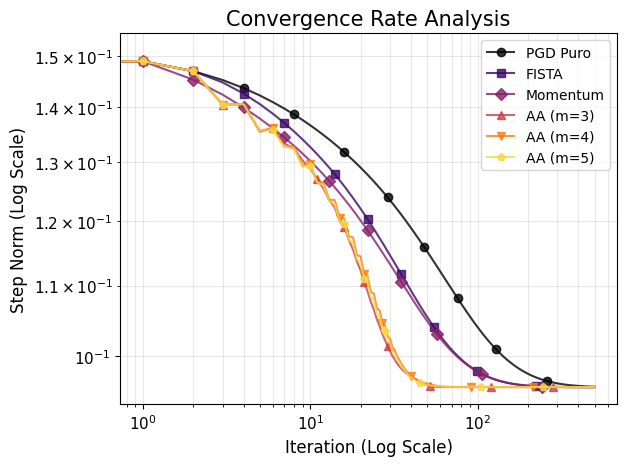

In [ ]:
def plot_convergence_rates(residual_results, labels):
    plt.figure()

    # Marcadores y colores para que quede igual de "pro" que la anterior
    markers = ['o', 's', 'D', '^', 'v', 'p', 'X']
    colors = plt.cm.inferno(np.linspace(0, 0.9, len(residual_results)))

    for i, action in enumerate(residual_results.keys()):
        plt.plot(residual_results[action],
                 label=labels[action],
                 color=colors[i],
                 marker=markers[i % len(markers)],
                 markevery=0.1,
                 alpha=0.8,
                 linewidth=1.5)

    plt.yscale('log') # CRÍTICO: El residuo siempre se ve en logarítmico
    plt.xscale('log') # Opcional: para ver el inicio con detalle

    plt.title(r"Convergence Rate Analysis", fontsize=15)
    plt.xlabel("Iteration (Log Scale)", fontsize=12)
    plt.ylabel("Step Norm (Log Scale)", fontsize=12)
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend(loc='best', fontsize=10)

    plt.tight_layout()
    plt.show()

plot_convergence_rates(residual_results, action_labels)

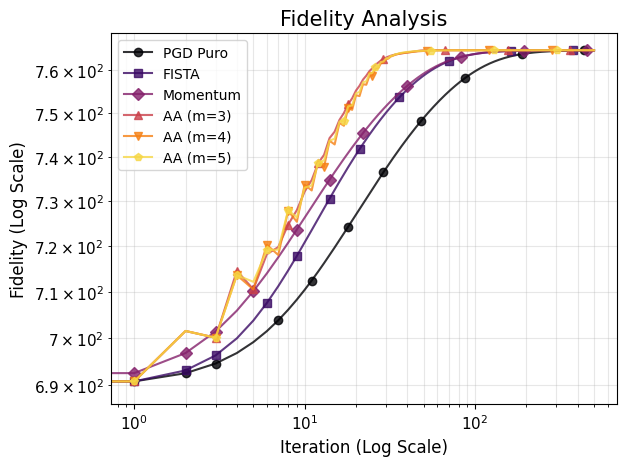

In [ ]:
def plot_fidelity(fid_results, labels):
    plt.figure()

    # Marcadores y colores para que quede igual de "pro" que la anterior
    markers = ['o', 's', 'D', '^', 'v', 'p', 'X']
    colors = plt.cm.inferno(np.linspace(0, 0.9, len(fid_results)))

    for i, action in enumerate(fid_results.keys()):
        plt.plot(fid_results[action],
                 label=labels[action],
                 color=colors[i],
                 marker=markers[i % len(markers)],
                 markevery=0.1,
                 alpha=0.8,
                 linewidth=1.5)

    plt.yscale('log') # CRÍTICO: El residuo siempre se ve en logarítmico
    plt.xscale('log') # Opcional: para ver el inicio con detalle

    plt.title(r"Fidelity Analysis", fontsize=15)
    plt.xlabel("Iteration (Log Scale)", fontsize=12)
    plt.ylabel("Fidelity (Log Scale)", fontsize=12)
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend(loc='best', fontsize=10)

    plt.tight_layout()
    plt.show()

plot_fidelity(fid_results, action_labels)

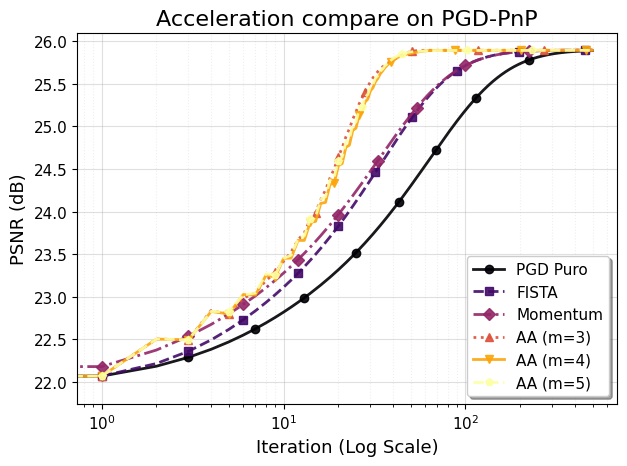

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_reconstruction_log_chimbita(results, labels):
    # Definimos estilos para que cada línea sea única
    # Marcadores: o (círculo), s (cuadrado), D (diamante), ^ (triángulo), v (triángulo abajo), p (pentágono), * (estrella)
    markers = ['o', 's', 'D', '^', 'v', 'p', '*']
    linestyles = ['-', '--', '-.', ':', '-', '--', '-.']
    colors = plt.cm.inferno(np.linspace(0, 1, len(results))) # Paleta de colores profesional

    plt.figure()

    for i, (action, values) in enumerate(results.items()):
        # Usamos markevery para no saturar la gráfica de símbolos en escala log
        # Esto pone un marcador cada cierto tramo logarítmico
        plt.plot(values,
                 label=labels[action],
                 color=colors[i],
                 linestyle=linestyles[i % len(linestyles)],
                 marker=markers[i % len(markers)],
                 markevery=0.1, # Pone marcadores al 10%, 20%, etc. del progreso
                 markersize=6,
                 linewidth=2,
                 alpha=0.9)

    # Configuración de escalas
    plt.xscale('log')
    plt.yscale('linear') # PSNR se aprecia mejor en lineal

    # Etiquetas y Estética
    plt.title("Acceleration compare on PGD-PnP", fontsize=16)
    plt.xlabel("Iteration (Log Scale)", fontsize=13)
    plt.ylabel("PSNR (dB)", fontsize=13)

    # Rejilla detallada para escala logarítmica
    plt.grid(True, which="both", ls="-", alpha=0.4)
    plt.grid(True, which="minor", ls=":", alpha=0.2)

    plt.legend(loc='lower right', frameon=True, shadow=True, fontsize=11)

    # Ajustar márgenes
    plt.tight_layout()
    plt.show()

# Ejecutar
plot_reconstruction_log_chimbita(results, action_labels)

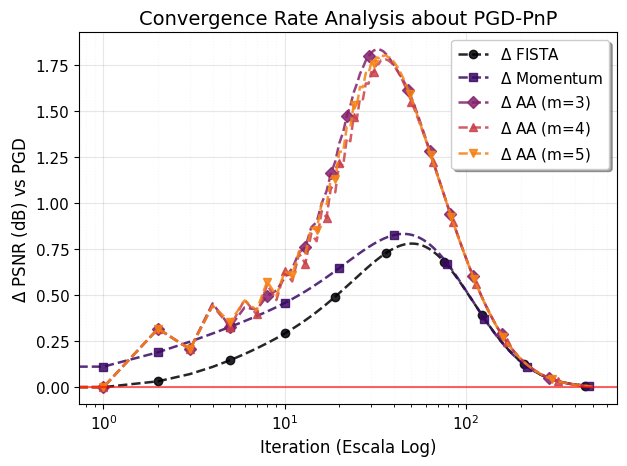

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_performance_gain_analysis(results, labels, metric_name="PSNR (dB)"):
    # Configuración de estilo
    plt.rcParams.update({'font.size': 11})

    # Marcadores y estilos
    markers = ['o', 's', 'D', '^', 'v', 'p', 'X']
    linestyles = ['--', '--', '--', '--', '--', '--', '--']
    colors = plt.cm.inferno(np.linspace(0, 0.9, len(results)))

    plt.figure()

    # Referencia base: Acción 0 (PGD Puro)
    base_values = np.array(results[0])

    # Filtrar acciones para comparar (excluimos la base)
    actions_to_compare = [a for a in results.keys() if a != 0]

    for i, action in enumerate(actions_to_compare):
        # Diferencia respecto a la base
        delta_metric = np.array(results[action]) - base_values

        # Usamos r"" para evitar el SyntaxWarning con \Delta
        plt.plot(delta_metric,
                 label=fr"$\Delta$ {labels[action]}",
                 color=colors[i],
                 linestyle=linestyles[i % len(linestyles)],
                 marker=markers[i % len(markers)],
                 markevery=0.1,
                 markersize=6,
                 linewidth=1.8,
                 alpha=0.85)

    # Escala logarítmica en X
    plt.xscale('log')

    # Línea de referencia en cero
    plt.axhline(0, color='red', lw=1.5, ls='-', alpha=0.6)

    plt.title("Convergence Rate Analysis about PGD-PnP", fontsize=14)
    plt.xlabel("Iteration (Escala Log)", fontsize=12)
    # Usamos r"" aquí también para el eje Y
    plt.ylabel(fr"$\Delta$ {metric_name} vs PGD", fontsize=12)

    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.grid(True, which="minor", ls=":", alpha=0.1)

    plt.legend(loc='best', frameon=True, shadow=True)

    plt.tight_layout()
    plt.show()

# Ejecutar el análisis corregido
plot_performance_gain_analysis(results, action_labels)

In [ ]:
PSNRs = []
max_iter = 1000
x_k = x0
with torch.inference_mode():
    for k in tqdm(range(max_iter), colour='magenta', desc="PGD Step"):
        x_k = pgd.step(x_k, y, physics)
        PSNRs.append(metric(x_k, x).item())

PGD Step: 100%|██████████| 1000/1000 [00:22<00:00, 44.48it/s]


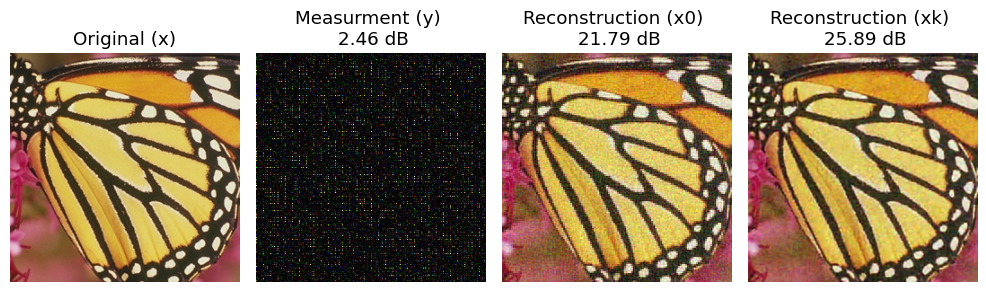

In [ ]:
# PLOT

plt.figure(figsize=(10,10))
plt.subplot(1, 4, 1)
plt.imshow(x.cpu().squeeze(0).permute(1,2,0))
plt.title('Original (x)')
plt.axis('off')
plt.subplot(1, 4, 2)
plt.imshow(y.cpu().squeeze().permute(1,2,0))
plt.title(f'Measurment (y) \n {metric(y, x).item():.2f} dB')
plt.axis('off')
plt.subplot(1, 4, 3)
plt.imshow(x0.cpu().squeeze().permute(1,2,0))
plt.title(f'Reconstruction (x0) \n {metric(x0, x).item():.2f} dB')
plt.axis('off')
plt.subplot(1, 4, 4)
plt.imshow(x_k.cpu().squeeze().permute(1,2,0).detach().numpy())
plt.title(f'Reconstruction (xk) \n {metric(x_k, x).item():.2f} dB')
plt.axis('off')
plt.tight_layout()
plt.show()

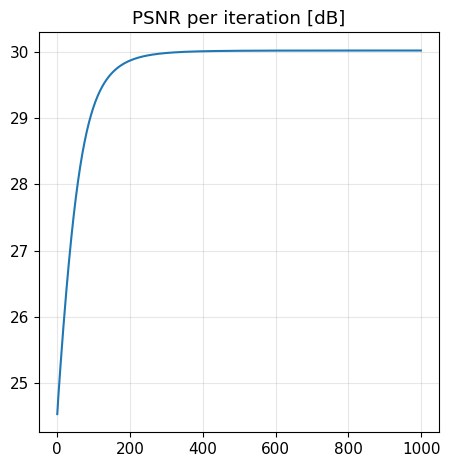

In [ ]:
plt.figure()
plt.plot(PSNRs)
plt.title(f'PSNR per iteration [dB]')
plt.gca().set_box_aspect(1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()